# Implementación de modelos de Redes Neuronales Profundas

En este archivo, voy a poner en práctica lo aprendido a lo largo de la asignatura tanto en la parte de teoría como en la parte de práctica. La idea es crear una CNN capaz de analizar radiografías de tórax y clasificarlas en tres categorías: pacientes sanos, con neumonía bacteriana y con neumonía vírica.

**Realizado por Rodrigo Gálvez Travalja**

---

## Estructura del notebook
1. Instalación e importación de librerías
2. Comprobación de GPU
3. Descarga del dataset
4. Preprocesamiento e imágenes
5. Definición de la CNN
6. Entrenamiento y validación
7. Predicción y visualización
8. Guardado del modelo

## 1. Instalación e importación de librerías

In [37]:
%pip install torch torchvision kagglehub matplotlib pandas scikit-learn --quiet

import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

import kagglehub

# Añadir raíz del proyecto al path para importar desde app/
sys.path.insert(0, os.path.abspath('..'))

# Importar arquitectura de modelo desde app/model/architecture.py
from app.model.architecture import PneumoniaCNN, CLASS_NAMES

print('Librerías importadas correctamente.')

Note: you may need to restart the kernel to use updated packages.
Librerías importadas correctamente.


## 2. Comprobación de GPU y configuración del device

In [38]:
# Verificar disponibilidad de CUDA/MPS y seleccionar device
print(f'Versión de PyTorch: {torch.__version__}')
print(f'CUDA disponible:    {torch.cuda.is_available()}')
print(f'MPS disponible:     {torch.backends.mps.is_available()}')

if torch.cuda.is_available():
    print(f'GPU (CUDA):         {torch.cuda.get_device_name(0)}')
    print(f'Versión CUDA:       {torch.version.cuda}')
elif torch.backends.mps.is_available():
    print(f'GPU (MPS):          Apple Silicon')

# Prioridad: CUDA (Windows/Linux con GPU) → MPS (Mac Apple Silicon) → CPU
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'\nUsando device: {device}')

Versión de PyTorch: 2.11.0+cu130
CUDA disponible:    True
MPS disponible:     False
GPU (CUDA):         NVIDIA GeForce RTX 4060 Ti
Versión CUDA:       13.0

Usando device: cuda


In [39]:
# Configuración global: tamaño de imagen y normalización
TAMANIO_IMAGEN = (100, 100)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Nombres de las clases (3 clases: Normal, Neumonía Bacteriana, Neumonía Vírica)
NOMBRES_CLASES = ['NORMAL', 'PNEUMONIA_BACTERIAL', 'PNEUMONIA_VIRAL']

print(f'Tamaño de imagen: {TAMANIO_IMAGEN}')
print(f'Clases: {NOMBRES_CLASES}')

Tamaño de imagen: (100, 100)
Clases: ['NORMAL', 'PNEUMONIA_BACTERIAL', 'PNEUMONIA_VIRAL']


## 3. Descarga del dataset desde Kaggle

In [40]:
# Descarga del dataset Chest X-Ray Images (Pneumonia)
ruta = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print(f'Dataset descargado en: {ruta}')

# Rutas a los splits del dataset
ruta_datos    = os.path.join(ruta, 'chest_xray')
RUTA_TRAIN    = os.path.join(ruta_datos, 'train')
RUTA_VAL      = os.path.join(ruta_datos, 'val')
RUTA_TEST     = os.path.join(ruta_datos, 'test')   # minúsculas: Linux es case-sensitive

# Verificar que las carpetas existen
for nombre, ruta_split in [('train', RUTA_TRAIN), ('val', RUTA_VAL), ('test', RUTA_TEST)]:
    existe = os.path.isdir(ruta_split)
    print(f'  {nombre}: {ruta_split} → {"OK" if existe else "NO ENCONTRADA"}')

Dataset descargado en: /home/rodrigo_galvez/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
  train: /home/rodrigo_galvez/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train → OK
  val: /home/rodrigo_galvez/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/val → OK
  test: /home/rodrigo_galvez/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test → OK


## 4. Preprocesamiento e imágenes

El dataset de Kaggle organiza las imágenes en dos carpetas: `NORMAL` y `PNEUMONIA`.
Dentro de `PNEUMONIA`, el nombre del fichero indica si es bacteriana (`bacteria`) o vírica (`virus`).
Creamos un Dataset personalizado que lee esta estructura y asigna las etiquetas correctas para la clasificación en 3 clases.

In [41]:
# Transformaciones para entrenamiento (con data augmentation)
transformacion_entrenamiento = transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## 5. Definición de la CNN

Arquitectura de 3 bloques convolucionales seguidos de capas fully connected.
Cada bloque aplica Conv2d + ReLU + MaxPool2d(2,2), reduciendo la resolución a la mitad.
Con input 100×100: 100 → 50 → 25 → 12, por lo que la capa FC recibe 128 × 12 × 12 = 18432 características.

In [42]:
# PneumoniaCNN ya está importada en la celda de importaciones
# Misma clase que usa el wrapper de inferencia → garantiza consistencia total
modelo = PneumoniaCNN(num_classes=3).to(device)
print(modelo)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

PneumoniaCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=18432, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Parámetros entrenables: 2,453,059


In [43]:
# Dataset personalizado para cargar radiografías desde estructura Kaggle
class DatasetRayosX(Dataset):
    """
    Dataset personalizado para radiografías de tórax.
    Lee estructura típica Kaggle:
      train/NORMAL/*
      train/PNEUMONIA/bacteria/* or train/PNEUMONIA/virus/*
    Y también maneja imágenes directamente en train/PNEUMONIA/ con nombres que incluyen 'bacteria' o 'virus'.
    """
    def __init__(self, ruta_raiz, transformaciones=None):
        self.imagenes = []
        self.etiquetas = []
        self.transformaciones = transformaciones

        # Clase 0: NORMAL
        ruta_normal = os.path.join(ruta_raiz, 'NORMAL')
        if os.path.exists(ruta_normal):
            for imagen in glob.glob(os.path.join(ruta_normal, '*')):
                if os.path.isfile(imagen):
                    self.imagenes.append(imagen)
                    self.etiquetas.append(0)

        # Clase 1 y 2: PNEUMONIA (subcarpetas bacteria / virus) o archivos directos
        ruta_pneumonia = os.path.join(ruta_raiz, 'PNEUMONIA')
        if os.path.exists(ruta_pneumonia):
            # 1) Archivos directamente bajo PNEUMONIA/
            archivos_root = [p for p in glob.glob(os.path.join(ruta_pneumonia, '*')) if os.path.isfile(p)]
            añadidos_root = 0
            for imagen in archivos_root:
                nombre = os.path.basename(imagen).lower()
                if 'virus' in nombre or 'viral' in nombre:
                    etiqueta = 2
                elif 'bacteria' in nombre:
                    etiqueta = 1
                else:
                    continue
                self.imagenes.append(imagen)
                self.etiquetas.append(etiqueta)
                añadidos_root += 1

            # 2) Subdirectorios dentro de PNEUMONIA/
            añadidos_subdirs = 0
            for entrada in os.listdir(ruta_pneumonia):
                path_entrada = os.path.join(ruta_pneumonia, entrada)
                if not os.path.isdir(path_entrada):
                    continue
                name_lower = entrada.lower()
                if 'bacteria' in name_lower:
                    etiqueta = 1
                elif 'virus' in name_lower or 'viral' in name_lower:
                    etiqueta = 2
                else:
                    etiqueta = None
                for imagen in glob.glob(os.path.join(path_entrada, '*')):
                    if not os.path.isfile(imagen):
                        continue
                    if etiqueta is None:
                        img_lower = os.path.basename(imagen).lower()
                        if 'virus' in img_lower or 'viral' in img_lower:
                            etiqueta = 2
                        elif 'bacteria' in img_lower:
                            etiqueta = 1
                        else:
                            continue
                    self.imagenes.append(imagen)
                    self.etiquetas.append(etiqueta)
                    añadidos_subdirs += 1

            if añadidos_root > 0:
                print(f'Nota: se añadieron {añadidos_root} imágenes encontradas directamente en PNEUMONIA/')
            if añadidos_subdirs == 0 and añadidos_root == 0:
                print('⚠️ Aviso: no se encontraron imágenes en PNEUMONIA/ (ni en subcarpetas ni en raíz)')

    def __len__(self):
        return len(self.imagenes)

    def __getitem__(self, idx):
        imagen = Image.open(self.imagenes[idx]).convert('RGB')
        if self.transformaciones:
            imagen = self.transformaciones(imagen)
        return imagen, self.etiquetas[idx]


# Crear datasets para train y val
dataset_train = DatasetRayosX(RUTA_TRAIN, transformacion_entrenamiento)
dataset_val   = DatasetRayosX(RUTA_VAL,   transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
]))

print(f'Dataset train: {len(dataset_train)} imágenes')
print(f'Dataset val:   {len(dataset_val)} imágenes')

# Contar clases para calcular pesos (corregir desbalanceo)
contador_train = Counter(dataset_train.etiquetas)
print(f'\nDistribución clases (train): {dict(contador_train)}')

# Crear dataloaders
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=32, shuffle=False)

print(f'\nBatches train: {len(loader_train)}')
print(f'Batches val:   {len(loader_val)}')

# Calcular pesos de clases (inverso de frecuencia) evitando división por cero
counts = [contador_train.get(i, 0) for i in range(3)]
for i, c in enumerate(counts):
    if c == 0:
        print(f"⚠️ Aviso: no se han encontrado ejemplos para la clase {i} ({NOMBRES_CLASES[i]}).")

# Evitar división por cero usando max(count, 1)
total_samples = sum(counts) if sum(counts) > 0 else max(1, len(dataset_train))
pesos = [total_samples / (max(c, 1) * 3) for c in counts]
pesos_clases = torch.tensor(pesos, dtype=torch.float32)

print(f'\nPesos de clases (corrección desbalanceo):')
for i, (clase, peso, c) in enumerate(zip(NOMBRES_CLASES, pesos_clases, counts)):
    print(f'  {clase}: peso = {peso:.4f} (n={c})')

Nota: se añadieron 3875 imágenes encontradas directamente en PNEUMONIA/
Nota: se añadieron 8 imágenes encontradas directamente en PNEUMONIA/
Dataset train: 5216 imágenes
Dataset val:   16 imágenes

Distribución clases (train): {0: 1341, 2: 1345, 1: 2530}

Batches train: 163
Batches val:   1

Pesos de clases (corrección desbalanceo):
  NORMAL: peso = 1.2965 (n=1341)
  PNEUMONIA_BACTERIAL: peso = 0.6872 (n=2530)
  PNEUMONIA_VIRAL: peso = 1.2927 (n=1345)


In [47]:
# Preparar dataset y dataloader de test (antes de llamar a evaluar_en_test)
dataset_test = DatasetRayosX(RUTA_TEST, transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
]))
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)
print(f'Dataset test: {len(dataset_test)} imágenes — Batches: {len(loader_test)}')


Nota: se añadieron 390 imágenes encontradas directamente en PNEUMONIA/
Dataset test: 624 imágenes — Batches: 20


## 6. Entrenamiento y validación

Criterio de parada: loss de entrenamiento ≤ 0.2.

In [48]:
def entrenar_modelo(modelo, loader_train, loader_val, pesos_clases, num_epocas=20, lr=0.001, patience=5):
    """
    Entrena el modelo y evalúa en validación cada época.
    
    ESTRATEGIA PROFESIONAL (Senior ML):
    - Guarda por BALANCED ACCURACY (promedio de recalls), no por loss
    - Esto evita overfitting a clases mayoritarias en datasets desbalanceados
    - En medicina: penaliza fuertemente si cualquier clase baja su recall
    
    Args:
        pesos_clases: Tensor con pesos por clase para CrossEntropyLoss
        patience: Épocas sin mejora antes de parar (robusto para medicina: 5 épocas)
    """
    from sklearn.metrics import confusion_matrix, recall_score
    
    optimizador = optim.RMSprop(modelo.parameters(), lr=lr)
    criterio    = nn.CrossEntropyLoss(weight=pesos_clases.to(device))

    perdidas_train,    perdidas_val     = [], []
    precisiones_train, precisiones_val  = [], []
    balanced_accs_val = []
    
    mejor_bal_acc = 0.0  # Métrica profesional: Balanced Accuracy
    epocas_sin_mejora = 0
    mejor_epoca = 0
    mejor_checkpoint = None

    for epoca in range(num_epocas):

        # --- Fase de entrenamiento ---
        modelo.train()
        perdida_acum = 0.0
        correctos    = 0
        total        = 0

        for entradas, etiquetas in loader_train:
            entradas  = entradas.to(device)
            etiquetas = etiquetas.to(device)

            optimizador.zero_grad()
            salidas = modelo(entradas)
            perdida = criterio(salidas, etiquetas)
            perdida.backward()
            optimizador.step()

            perdida_acum += perdida.item()
            _, predicho   = torch.max(salidas, 1)
            correctos     += (predicho == etiquetas).sum().item()
            total         += etiquetas.size(0)

        loss_train = perdida_acum / len(loader_train)
        acc_train  = 100 * correctos / total
        perdidas_train.append(loss_train)
        precisiones_train.append(acc_train)

        # --- Fase de validación ---
        modelo.eval()
        todas_pred_val = []
        todas_etiq_val = []
        perdida_val_acum = 0.0

        with torch.no_grad():
            for entradas, etiquetas in loader_val:
                entradas  = entradas.to(device)
                etiquetas = etiquetas.to(device)

                salidas = modelo(entradas)
                perdida = criterio(salidas, etiquetas)

                perdida_val_acum += perdida.item()
                _, predicho = torch.max(salidas, 1)
                todas_pred_val.extend(predicho.cpu().numpy())
                todas_etiq_val.extend(etiquetas.cpu().numpy())

        loss_val = perdida_val_acum / len(loader_val)
        acc_val  = 100 * sum(p == e for p, e in zip(todas_pred_val, todas_etiq_val)) / len(todas_etiq_val)
        
        # MÉTRICA PROFESIONAL: Balanced Accuracy
        # = promedio de recall por clase → penaliza si cualquier clase baja
        recalls_por_clase = recall_score(todas_etiq_val, todas_pred_val, average=None, zero_division=0)
        balanced_acc = np.mean(recalls_por_clase) * 100
        balanced_accs_val.append(balanced_acc)
        
        perdidas_val.append(loss_val)
        precisiones_val.append(acc_val)

        # Decisión: Guardar por Balanced Accuracy (no por loss)
        marca_mejor = ""
        if balanced_acc > mejor_bal_acc:
            mejor_bal_acc = balanced_acc
            epocas_sin_mejora = 0
            mejor_epoca = epoca + 1
            mejor_checkpoint = modelo.state_dict().copy()
            marca_mejor = " ⭐ MEJOR"
        else:
            epocas_sin_mejora += 1

        # Log detallado (información profesional)
        print(f'Época {epoca+1:02d}/{num_epocas} | '
              f'Loss train: {loss_train:.4f}  Acc train: {acc_train:.2f}% | '
              f'Acc val: {acc_val:.2f}%  Bal.Acc: {balanced_acc:.2f}%{marca_mejor}')
        
        # Detalle por clase cada 5 épocas
        if (epoca + 1) % 5 == 0 or marca_mejor:
            for i, recall_i in enumerate(recalls_por_clase):
                print(f'           → {NOMBRES_CLASES[i]}: recall = {recall_i*100:.2f}%')

        # Early stopping: menos agresivo, basado en balanced accuracy
        if epocas_sin_mejora >= patience:
            print(f'\n🛑 Early stopping: Balanced Accuracy sin mejora durante {patience} épocas.')
            print(f'   Mejor modelo guardado en época {mejor_epoca} con Bal.Acc = {mejor_bal_acc:.2f}%')
            break

    # Cargar el mejor modelo
    if mejor_checkpoint is not None:
        modelo.load_state_dict(mejor_checkpoint)
        print(f'\n✓ Mejor modelo cargado (época {mejor_epoca}, Bal.Acc = {mejor_bal_acc:.2f}%)')
    else:
        print('\n⚠️ No se guardó checkpoint (mejor_checkpoint es None)')

    return modelo, perdidas_train, perdidas_val, precisiones_train, precisiones_val


modelo, perdidas_train, perdidas_val, precisiones_train, precisiones_val = entrenar_modelo(
    modelo, loader_train, loader_val, pesos_clases, num_epocas=20, lr=0.001, patience=5
)

Época 01/20 | Loss train: 0.5462  Acc train: 74.85% | Acc val: 50.00%  Bal.Acc: 33.33% ⭐ MEJOR
           → NORMAL: recall = 62.50%
           → PNEUMONIA_BACTERIAL: recall = 37.50%
           → PNEUMONIA_VIRAL: recall = 0.00%
Época 02/20 | Loss train: 0.4804  Acc train: 77.42% | Acc val: 37.50%  Bal.Acc: 25.00%
Época 03/20 | Loss train: 0.4758  Acc train: 77.68% | Acc val: 43.75%  Bal.Acc: 29.17%
Época 04/20 | Loss train: 0.4521  Acc train: 78.14% | Acc val: 43.75%  Bal.Acc: 29.17%
Época 05/20 | Loss train: 0.4563  Acc train: 78.60% | Acc val: 62.50%  Bal.Acc: 41.67% ⭐ MEJOR
           → NORMAL: recall = 87.50%
           → PNEUMONIA_BACTERIAL: recall = 37.50%
           → PNEUMONIA_VIRAL: recall = 0.00%
Época 06/20 | Loss train: 0.4474  Acc train: 79.08% | Acc val: 43.75%  Bal.Acc: 29.17%
Época 07/20 | Loss train: 0.4480  Acc train: 78.34% | Acc val: 56.25%  Bal.Acc: 37.50%
Época 08/20 | Loss train: 0.4371  Acc train: 79.51% | Acc val: 50.00%  Bal.Acc: 33.33%
Época 09/20 | Loss train

## 7. Visualización de métricas de entrenamiento

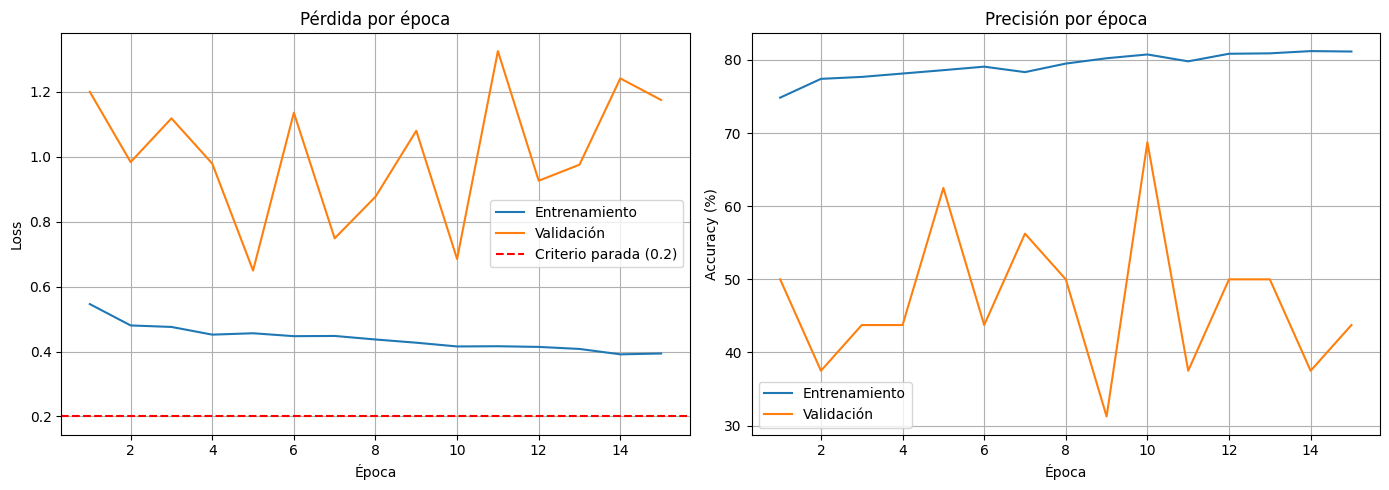

In [49]:
def mostrar_graficas(perdidas_train, perdidas_val, precisiones_train, precisiones_val):
    """Muestra las gráficas de loss y accuracy para train y validación."""
    epocas = range(1, len(perdidas_train) + 1)

    plt.figure(figsize=(14, 5))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epocas, perdidas_train, label='Entrenamiento')
    plt.plot(epocas, perdidas_val,   label='Validación')
    plt.axhline(y=0.2, color='r', linestyle='--', label='Criterio parada (0.2)')
    plt.title('Pérdida por época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Gráfica de precisión
    plt.subplot(1, 2, 2)
    plt.plot(epocas, precisiones_train, label='Entrenamiento')
    plt.plot(epocas, precisiones_val,   label='Validación')
    plt.title('Precisión por época')
    plt.xlabel('Época')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


mostrar_graficas(perdidas_train, perdidas_val, precisiones_train, precisiones_val)

## 8. Evaluación sobre el conjunto de test

Evaluación completa: accuracy global, métricas por clase (precision, recall, F1) y matriz de confusión.

Accuracy en test: 72.28%

                     precision    recall  f1-score   support

             NORMAL       0.96      0.47      0.63       234
PNEUMONIA_BACTERIAL       0.87      0.88      0.87       242
    PNEUMONIA_VIRAL       0.49      0.88      0.63       148

           accuracy                           0.72       624
          macro avg       0.77      0.74      0.71       624
       weighted avg       0.81      0.72      0.72       624



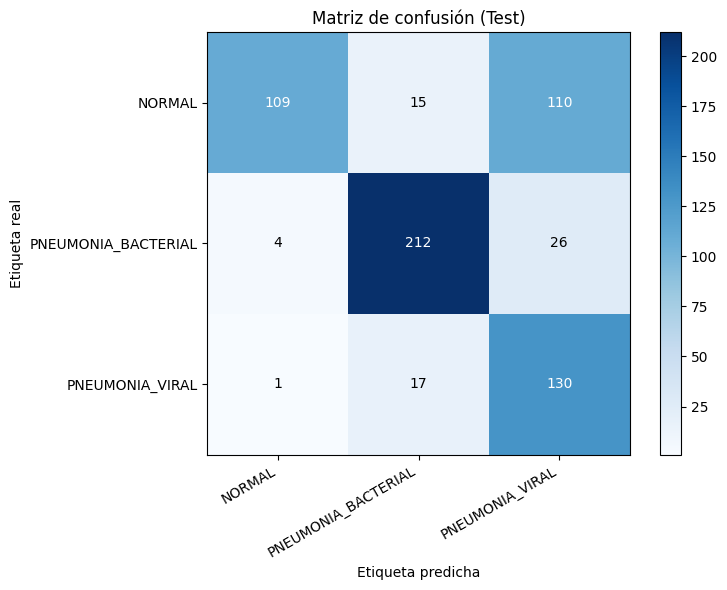


--- Ejemplos de predicciones individuales ---


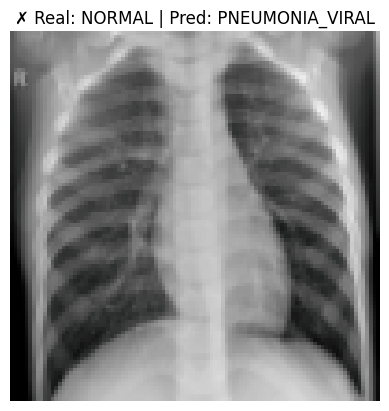

  PNEUMONIA_VIRAL           82.40%
  PNEUMONIA_BACTERIAL       11.38%
  NORMAL                    6.22%
----------------------------------------


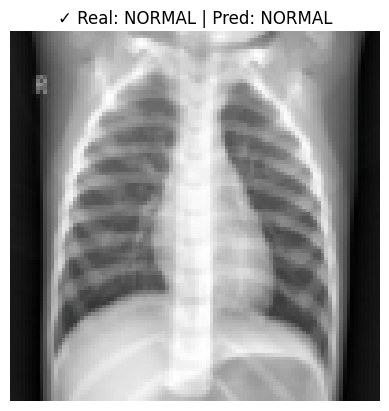

  NORMAL                    67.77%
  PNEUMONIA_VIRAL           30.62%
  PNEUMONIA_BACTERIAL       1.61%
----------------------------------------


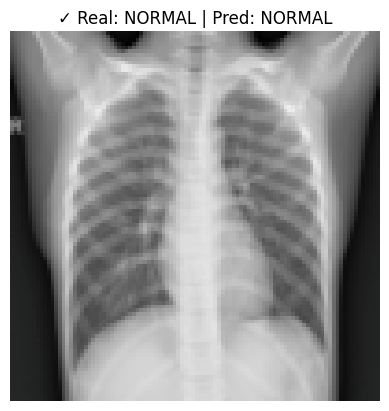

  NORMAL                    90.16%
  PNEUMONIA_VIRAL           8.99%
  PNEUMONIA_BACTERIAL       0.85%
----------------------------------------


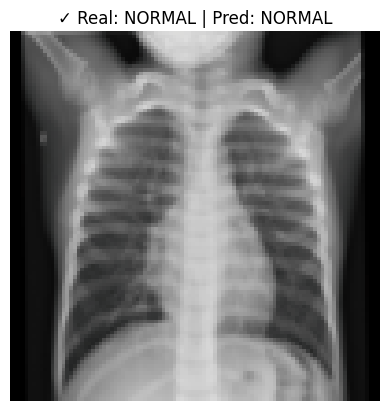

  NORMAL                    77.98%
  PNEUMONIA_VIRAL           15.76%
  PNEUMONIA_BACTERIAL       6.27%
----------------------------------------


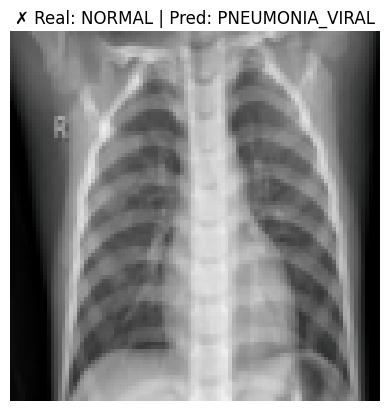

  PNEUMONIA_VIRAL           56.97%
  PNEUMONIA_BACTERIAL       43.02%
  NORMAL                    0.01%
----------------------------------------


In [50]:
# Definir función de desnormalización como helper global
def desnormalizar_imagen(tensor_normalizado, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Desnormaliza un tensor normalizado con ImageNet stats."""
    tensor = tensor_normalizado.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        tensor[i] = tensor[i] * s + m
    return torch.clamp(tensor, 0, 1)


def evaluar_en_test(modelo, loader_test, nombres_clases):
    """Calcula accuracy, métricas por clase y matriz de confusión sobre el test set."""
    
    modelo.eval()
    todas_predicciones = []
    todas_etiquetas    = []

    with torch.no_grad():
        for entradas, etiquetas in loader_test:
            entradas = entradas.to(device)
            salidas  = modelo(entradas)
            _, predicho = torch.max(salidas, 1)
            todas_predicciones.extend(predicho.cpu().numpy())
            todas_etiquetas.extend(etiquetas.numpy())

    # Accuracy global
    acc = 100 * sum(p == e for p, e in zip(todas_predicciones, todas_etiquetas)) / len(todas_etiquetas)
    print(f'Accuracy en test: {acc:.2f}%\n')

    # Métricas por clase: precision, recall, F1
    print(classification_report(todas_etiquetas, todas_predicciones, target_names=nombres_clases))

    # Matriz de confusión
    cm = confusion_matrix(todas_etiquetas, todas_predicciones)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de confusión (Test)')
    plt.colorbar()
    tick_marks = range(len(nombres_clases))
    plt.xticks(tick_marks, nombres_clases, rotation=30, ha='right')
    plt.yticks(tick_marks, nombres_clases)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.show()


evaluar_en_test(modelo, loader_test, NOMBRES_CLASES)

# Mostrar algunas predicciones individuales con probabilidades (DESNORMALIZADAS)
print('\n--- Ejemplos de predicciones individuales ---')
modelo.eval()
mostradas = 0
with torch.no_grad():
    for entradas, etiquetas in loader_test:
        entradas = entradas.to(device)
        salidas  = modelo(entradas)
        probs    = F.softmax(salidas, dim=1).cpu().numpy()

        for i in range(entradas.size(0)):
            if mostradas >= 5:
                break
            prob_imagen = probs[i]
            clase_pred  = NOMBRES_CLASES[np.argmax(prob_imagen)]
            clase_real  = NOMBRES_CLASES[etiquetas[i].item()]
            orden       = np.argsort(prob_imagen)[::-1]

            # Desnormalizar la imagen antes de visualizar
            tensor_desnorm = desnormalizar_imagen(entradas[i].cpu())
            imagen = to_pil_image(tensor_desnorm)
            plt.imshow(imagen, cmap='gray')
            plt.axis('off')
            acierto = '✓' if clase_pred == clase_real else '✗'
            plt.title(f'{acierto} Real: {clase_real} | Pred: {clase_pred}')
            plt.show()

            for idx in orden:
                print(f'  {NOMBRES_CLASES[idx]:<25} {prob_imagen[idx]*100:.2f}%')
            print('-' * 40)
            mostradas += 1

        if mostradas >= 5:
            break

## 9. Guardado del modelo    

Guardamos el `state_dict` junto con metadatos del modelo para que el wrapper de inferencia pueda cargarlo correctamente.

In [51]:
import os

# Ruta de guardado relativa al proyecto
RUTA_MODELO = os.path.join('..', 'models', 'model.pth')
os.makedirs(os.path.dirname(RUTA_MODELO), exist_ok=True)

# Guardar state_dict + metadatos
checkpoint = {
    'state_dict':       modelo.state_dict(),
    'num_clases':       3,
    'nombres_clases':   NOMBRES_CLASES,
    'tamanio_imagen':   TAMANIO_IMAGEN,
    'arquitectura':     'PneumoniaCNN'
}

torch.save(checkpoint, RUTA_MODELO)

# Verificar que el archivo se creó correctamente
tamanio_kb = os.path.getsize(RUTA_MODELO) / 1024
print(f'Modelo guardado en: {RUTA_MODELO}')
print(f'Tamaño del archivo: {tamanio_kb:.1f} KB')

# Verificación: cargar el modelo y hacer una predicción de prueba
print('\nVerificando carga del modelo...')
checkpoint_cargado = torch.load(RUTA_MODELO, map_location='cpu')
modelo_verificacion = PneumoniaCNN(num_classes=3)
modelo_verificacion.load_state_dict(checkpoint_cargado['state_dict'])
modelo_verificacion.eval()

tensor_prueba = torch.randn(1, 3, 100, 100)
with torch.no_grad():
    salida = modelo_verificacion(tensor_prueba)

print(f'Output shape: {list(salida.shape)}  ← esperado [1, 3]')
print('Modelo guardado y verificado correctamente.')

Modelo guardado en: ../models/model.pth
Tamaño del archivo: 9586.0 KB

Verificando carga del modelo...
Output shape: [1, 3]  ← esperado [1, 3]
Modelo guardado y verificado correctamente.
